In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("C:\\Users\\hp\\Documents\\ai-engineering-projects\\week1\\data\\application_train.csv")

In [6]:
print(f"Loaded {df.shape[0]} customers,{df.shape[1]} features")

Loaded 307511 customers,122 features


In [9]:
#age analysis
age_data=df['DAYS_BIRTH'].dropna()
age_data=-age_data/365.25
print(f"age range:{age_data.min():.1f} to {age_data.max():.1f} years")
print(f"average age {age_data.mean():.1f} years")

age range:20.5 to 69.1 years
average age 43.9 years


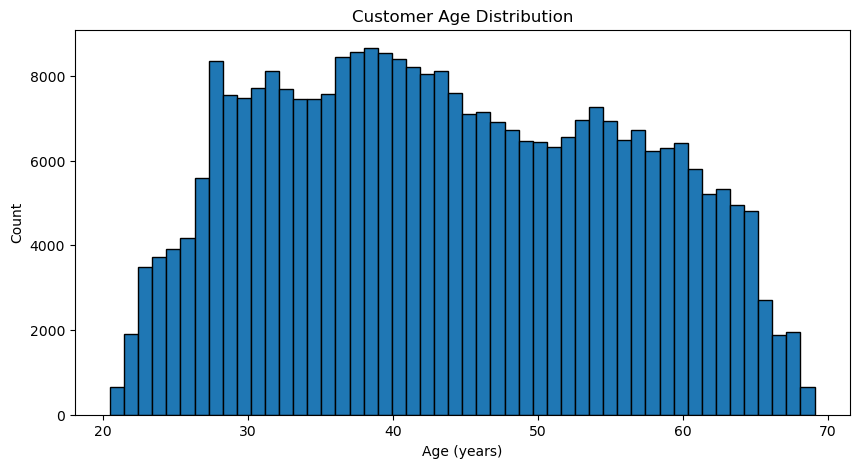

In [10]:
# Visualization
plt.figure(figsize=(10, 5))
plt.hist(age_data, bins=50, edgecolor='black')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.title('Customer Age Distribution')
plt.show()

In [11]:
#incme analysis
income=df['AMT_INCOME_TOTAL'].dropna()
print(f"income range: ${income.min():,.0f} to ${income.max():,.0f}")
print(f"average income: ${income.mean():,.0f}")
print(f"Median income: ${income.median():,.0f}")

income range: $25,650 to $117,000,000
average income: $168,798
Median income: $147,150


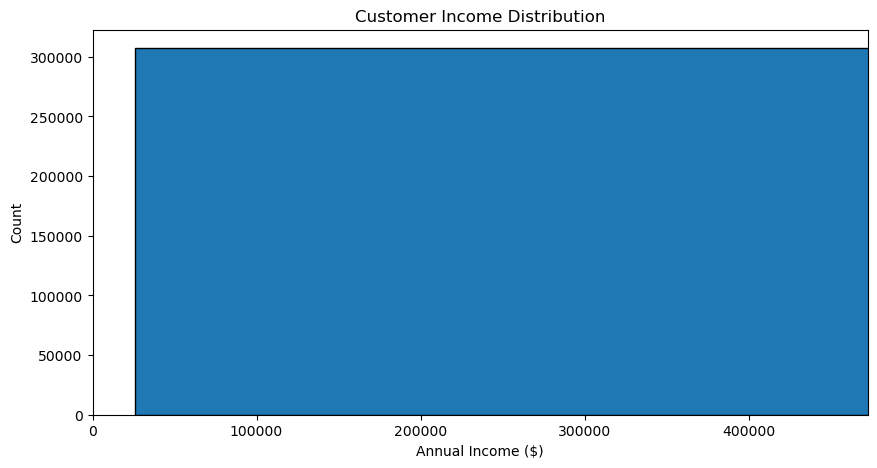

In [12]:
# Visualization
plt.figure(figsize=(10, 5))
plt.hist(income, bins=100, edgecolor='black')
plt.xlabel('Annual Income ($)')
plt.ylabel('Count')
plt.title('Customer Income Distribution')
plt.xlim([0, income.quantile(0.99)])  # Show 99% of data
plt.show()

Loan range: $45,000 to $4,050,000
Average loan: $599,026


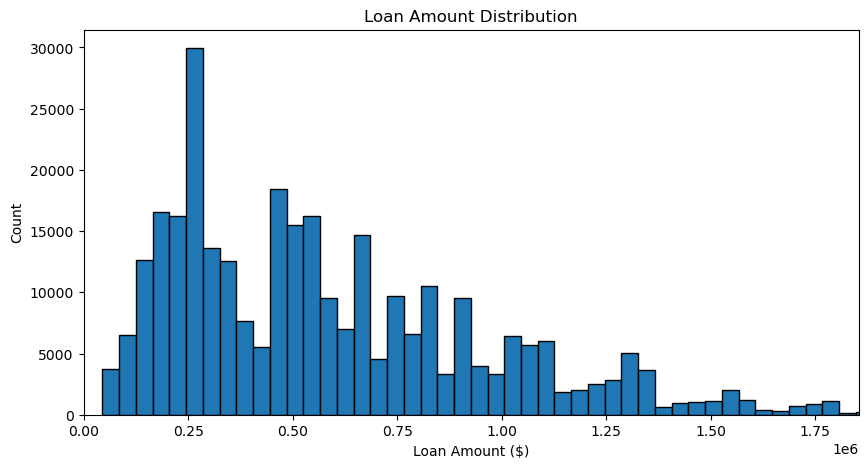

In [13]:
#loan amount analysis
loan = df['AMT_CREDIT'].dropna()

print(f"Loan range: ${loan.min():,.0f} to ${loan.max():,.0f}")
print(f"Average loan: ${loan.mean():,.0f}")

plt.figure(figsize=(10, 5))
plt.hist(loan, bins=100, edgecolor='black')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.title('Loan Amount Distribution')
plt.xlim([0, loan.quantile(0.99)])
plt.show()

Loan range: $45,000 to $4,050,000
Average loan: $599,026


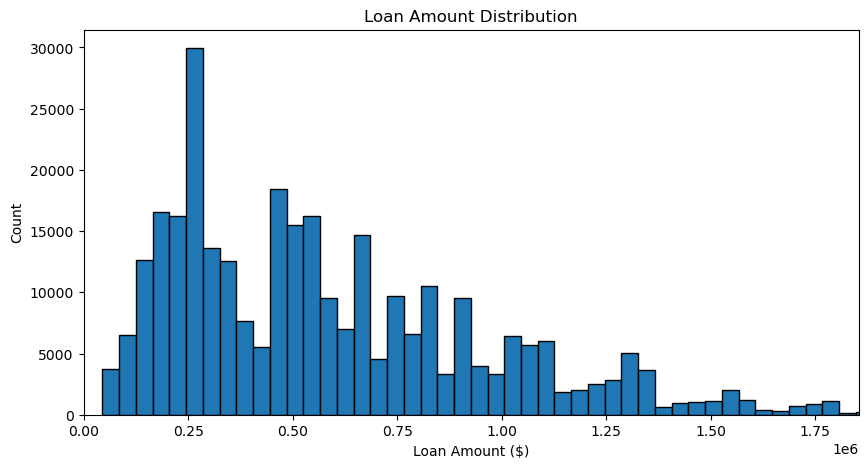

In [14]:
#loan amount analysis
loan = df['AMT_CREDIT'].dropna()

print(f"Loan range: ${loan.min():,.0f} to ${loan.max():,.0f}")
print(f"Average loan: ${loan.mean():,.0f}")

plt.figure(figsize=(10, 5))
plt.hist(loan, bins=100, edgecolor='black')
plt.xlabel('Loan Amount ($)')
plt.ylabel('Count')
plt.title('Loan Amount Distribution')
plt.xlim([0, loan.quantile(0.99)])
plt.show()


Gender distribution:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

Default rate by gender:
             Defaults   Total  Default_Rate
CODE_GENDER                                
F               14170  202448      0.069993
M               10655  105059      0.101419
XNA                 0       4      0.000000


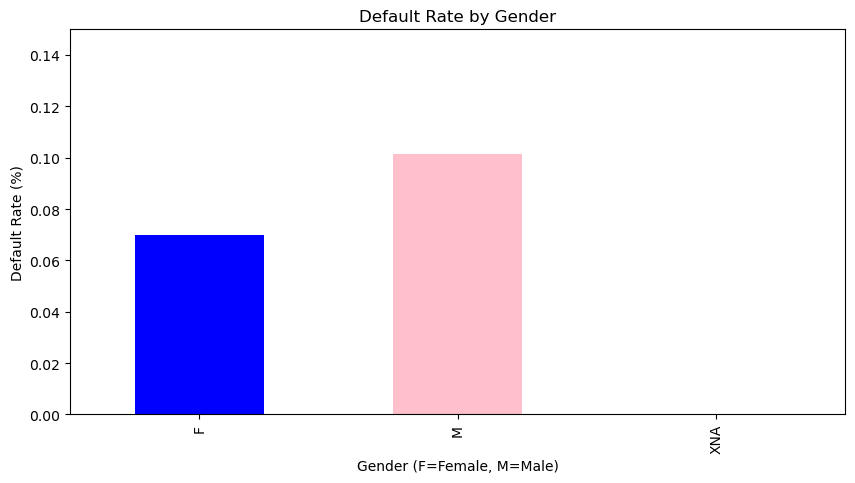

In [15]:
#gender analysis
print("Gender distribution:")
print(df['CODE_GENDER'].value_counts())

# Default rate by gender
default_by_gender = df.groupby('CODE_GENDER')['TARGET'].agg(['sum', 'count', 'mean'])
default_by_gender.columns = ['Defaults', 'Total', 'Default_Rate']
print("\nDefault rate by gender:")
print(default_by_gender)

# Visualization
plt.figure(figsize=(10, 5))
default_by_gender['Default_Rate'].plot(kind='bar', color=['blue', 'pink'])
plt.title('Default Rate by Gender')
plt.ylabel('Default Rate (%)')
plt.xlabel('Gender (F=Female, M=Male)')
plt.ylim([0, 0.15])
plt.show()

In [16]:
#family status analysis
print("family status distribution")
print(df['NAME_FAMILY_STATUS'].value_counts())

family status distribution
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64



Default rate by family status (%):
NAME_FAMILY_STATUS
Civil marriage          9.944584
Single / not married    9.807675
Separated               8.194234
Married                 7.559868
Widow                   5.824217
Unknown                 0.000000
Name: TARGET, dtype: float64


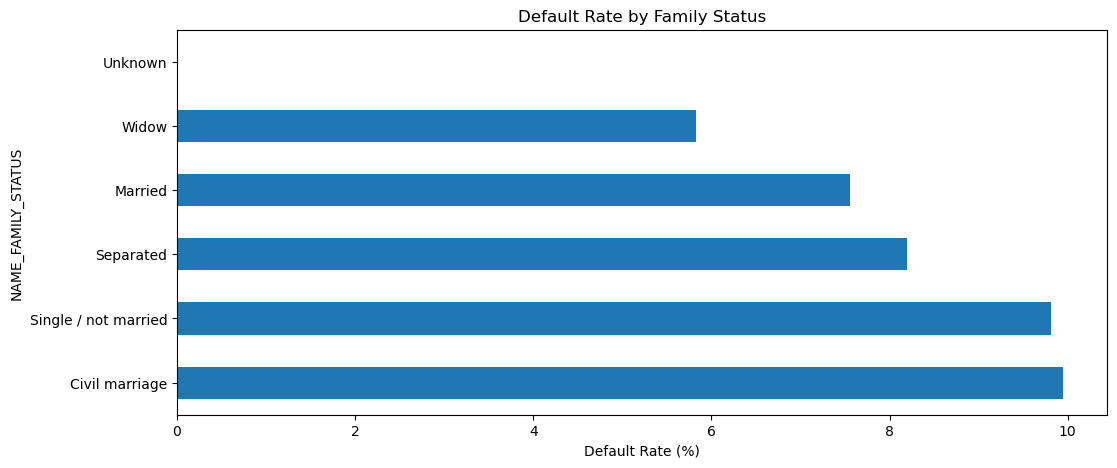

In [21]:
default_by_family=df.groupby('NAME_FAMILY_STATUS')['TARGET'].mean()*100
default_by_family=default_by_family.sort_values(ascending=False)
print("\nDefault rate by family status (%):")
print(default_by_family)

plt.figure(figsize=(12, 5))
default_by_family.plot(kind='barh')
plt.xlabel('Default Rate (%)')
plt.title('Default Rate by Family Status')
plt.show()


Education distribution:
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

Default rate by education (%):
NAME_EDUCATION_TYPE
Lower secondary                  10.927673
Secondary / secondary special     8.939929
Incomplete higher                 8.484966
Higher education                  5.355115
Academic degree                   1.829268
Name: TARGET, dtype: float64


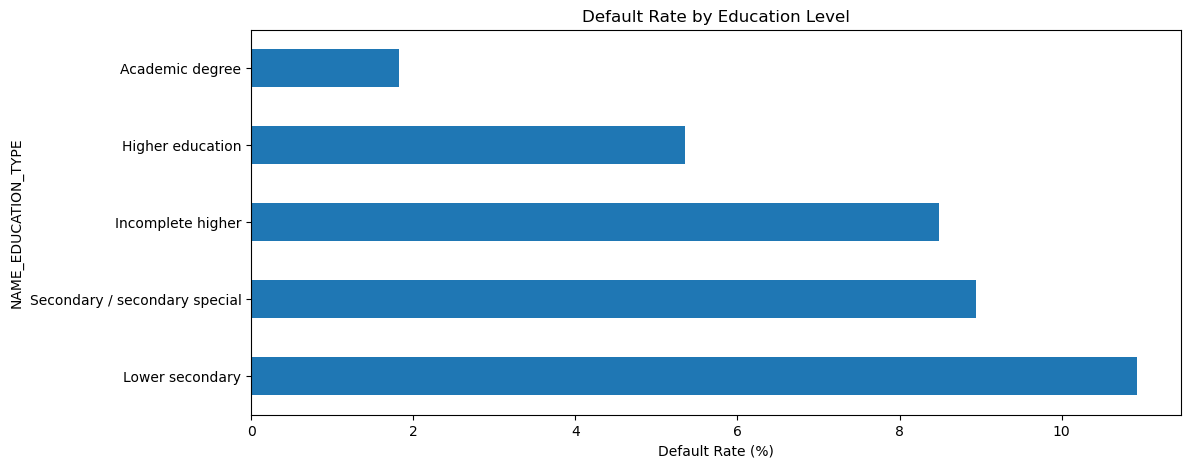

In [22]:
#education analysis
print("Education distribution:")
print(df['NAME_EDUCATION_TYPE'].value_counts())

# Default rate by education
default_by_edu = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean() * 100
default_by_edu = default_by_edu.sort_values(ascending=False)

print("\nDefault rate by education (%):")
print(default_by_edu)

plt.figure(figsize=(12, 5))
default_by_edu.plot(kind='barh')
plt.xlabel('Default Rate (%)')
plt.title('Default Rate by Education Level')
plt.show()


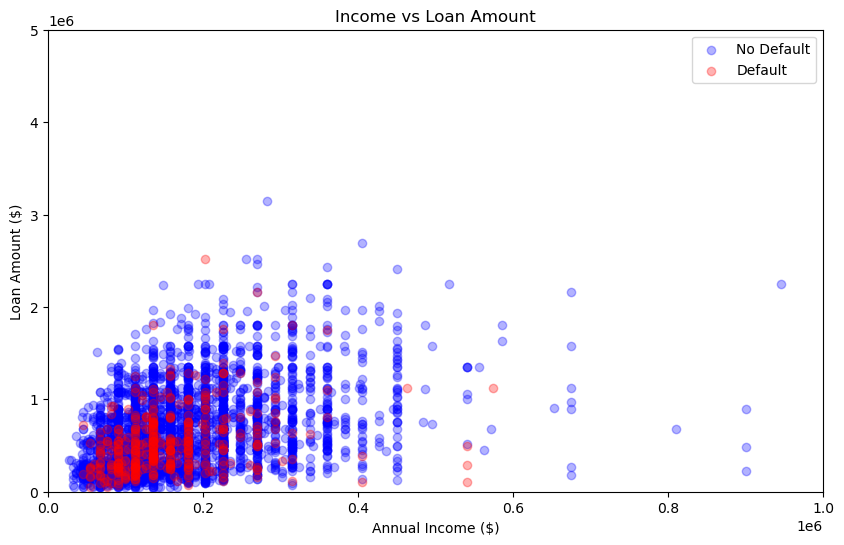

In [23]:
#income vs loan
sample = df.sample(n=5000)  # Use 5000 samples (faster plot)

plt.figure(figsize=(10, 6))
# Plot non-defaulters in blue
defaulters = sample[sample['TARGET'] == 1]
non_defaulters = sample[sample['TARGET'] == 0]

plt.scatter(non_defaulters['AMT_INCOME_TOTAL'], non_defaulters['AMT_CREDIT'], 
           alpha=0.3, color='blue', label='No Default')
plt.scatter(defaulters['AMT_INCOME_TOTAL'], defaulters['AMT_CREDIT'], 
           alpha=0.3, color='red', label='Default')

plt.xlabel('Annual Income ($)')
plt.ylabel('Loan Amount ($)')
plt.title('Income vs Loan Amount')
plt.legend()
plt.xlim([0, 1000000])
plt.ylim([0, 5000000])
plt.show()


In [25]:
#SUMMARY
print("="*60)
print("key findings from eda")
print("="*60)
print(f"\n1. Age: most customers are {age_data.mode()[0]:.0f} years old")
print(f"2. income: average ${df['AMT_INCOME_TOTAL'].mean():,.0f}/year")
print(f"3. Gender: {df['CODE_GENDER'].value_counts().index[0]} = {df['CODE_GENDER'].value_counts().iloc[0]} customers")
print(f"4. Default rate: {df['TARGET'].mean()*100:.1f}% (class imbalance!)")

print("\n5. Features most related to default:")
for col in ['DAYS_BIRTH', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_EMPLOYED']:
    if col in df.columns:
        correlation = df[col].corr(df['TARGET'])
        print(f"   {col}: {correlation:.3f}")

print("="*60)



key findings from eda

1. Age: most customers are 38 years old
2. income: average $168,798/year
3. Gender: F = 202448 customers
4. Default rate: 8.1% (class imbalance!)

5. Features most related to default:
   DAYS_BIRTH: 0.078
   AMT_INCOME_TOTAL: -0.004
   AMT_CREDIT: -0.030
   DAYS_EMPLOYED: -0.045
